# RAG System Evaluation - Stage 1

This notebook evaluates the RAG (Retrieval-Augmented Generation) system for:

1. **Retrieval Accuracy** - Recall@K, Precision@K, MRR
2. **Performance** - Response times
3. **End-to-End Quality** - Answer quality assessment

**Test Dataset:** 10 queries covering policy, pricing, amenities, and restrictions

## 1. Setup

In [1]:
import os
import sys
from dotenv import load_dotenv

# Add parent directory to path
sys.path.append(os.path.abspath('..'))

# Load environment variables
load_dotenv()

print("✓ Setup complete")

✓ Setup complete


In [2]:
from chatbot.main import ParkingChatbot
from chatbot.evaluation import RAGEvaluator
from chatbot.nodes import _get_vector_store, _get_compression_retriever

print("✓ Imports successful")

✓ Imports successful


## 2. Initialize Components

In [3]:
print("Initializing components...")

# Initialize chatbot
chatbot = ParkingChatbot()

# Get retrieval components
vector_store = _get_vector_store()
retriever = _get_compression_retriever()

# Initialize evaluator
evaluator = RAGEvaluator()

print(f"✓ Initialized with {len(evaluator.test_cases)} test cases")

Initializing components...
Initializing Parking Reservation Chatbot...
✓ Chatbot ready!


/home/tamer/personal-projects/Chatbot-for-Parking-Space-Reservation/.venv/lib/python3.11/site-packages/milvus_lite/__init__.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


✓ Initialized with 10 test cases


## 3. View Test Cases

In [4]:
import pandas as pd

# Display test cases
test_df = pd.DataFrame([{
    "Query": tc["query"],
    "Category": tc["category"],
    "Keywords": ", ".join(tc["relevant_keywords"][:3]) + "..."
} for tc in evaluator.test_cases])

print("Test Cases:")
display(test_df)

Test Cases:


,Query,Category,Keywords
0,What are your operating hours?,policy,"24 hours, 8:00 AM, 8:00 PM..."
1,How much does parking cost per hour?,pricing,"$5.00, hour, price..."
2,Do you have EV charging?,amenities,"EV, electric, Level 2..."
3,Can I park my RV here?,restrictions,"RV, prohibited, vehicle..."
4,What is the cancellation policy?,policy,"cancellation, 30 minutes, $5.00..."
5,Where are accessible parking spots?,amenities,"accessible, Ground Floor, elevator..."
6,What's the daily maximum charge?,pricing,"daily, $35, maximum..."
7,Is there 24/7 security?,amenities,"security, CCTV, surveillance..."
8,Can I modify my reservation?,policy,"modification, 1 hour, change..."
9,What is the overnight rate?,pricing,"overnight, $15, 6:00 PM..."


## 4. Retrieval Evaluation

Tests the RAG retrieval pipeline:
- Vector search (Milvus)
- Reranking (Cross-Encoder)
- Metrics: Recall@K, Precision@K, MRR

In [5]:
print("Running retrieval evaluation...\n")

retrieval_metrics, retrieval_results = evaluator.evaluate_retrieval(
    vector_store=vector_store,
    retriever=retriever,
    k_values=[3, 10]
)

print("\n" + "="*70)
print("RETRIEVAL EVALUATION RESULTS")
print("="*70)

print(f"\nAverage Recall@3:     {retrieval_metrics['avg_recall_at_3']:.2%}")
print(f"Average Precision@3:  {retrieval_metrics['avg_precision_at_3']:.2%}")
print(f"Average Recall@10:    {retrieval_metrics['avg_recall_at_10']:.2%}")
print(f"Average Precision@10: {retrieval_metrics['avg_precision_at_10']:.2%}")
print(f"Average MRR:          {retrieval_metrics['avg_mrr']:.3f}")
print(f"Average Time:         {retrieval_metrics['avg_retrieval_time']:.3f}s")

print("\n" + "="*70)

Running retrieval evaluation...



I0000 00:00:1774428070.285168   57284 chttp2_transport.cc:1353] unix:/tmp/tmpeja5qmgo_parking.db.sock: Got goaway [11] err=UNAVAILABLE:GOAWAY received; Error code: 11; Debug Text: too_many_pings {grpc_status:14, http2_error:11}
E0000 00:00:1774428070.285217   57284 chttp2_transport.cc:1385] unix:/tmp/tmpeja5qmgo_parking.db.sock: Received a GOAWAY with error code ENHANCE_YOUR_CALM and debug data equal to "too_many_pings". Current keepalive time (before throttling): 10000ms



RETRIEVAL EVALUATION RESULTS

Average Recall@3:     63.33%
Average Precision@3:  63.33%
Average Recall@10:    79.17%
Average Precision@10: 38.75%
Average MRR:          1.000
Average Time:         1.229s



I0000 00:00:1774428193.342288   57434 chttp2_transport.cc:1353] unix:/tmp/tmpeja5qmgo_parking.db.sock: Got goaway [11] err=UNAVAILABLE:GOAWAY received; Error code: 11; Debug Text: too_many_pings {grpc_status:14, http2_error:11}
E0000 00:00:1774428193.342411   57434 chttp2_transport.cc:1385] unix:/tmp/tmpeja5qmgo_parking.db.sock: Received a GOAWAY with error code ENHANCE_YOUR_CALM and debug data equal to "too_many_pings". Current keepalive time (before throttling): 20000ms


### Detailed Retrieval Results

In [6]:
retrieval_df = pd.DataFrame([{
    "Query": r.query[:50] + "...",
    "Recall@3": f"{r.recall_at_3:.1%}",
    "Precision@3": f"{r.precision_at_3:.1%}",
    "MRR": f"{r.mrr:.3f}",
    "Time (s)": f"{r.retrieval_time:.3f}"
} for r in retrieval_results])

display(retrieval_df)

,Query,Recall@3,Precision@3,MRR,Time (s)
0,What are your operating hours?...,66.7%,66.7%,1.000,0.940
1,How much does parking cost per hour?...,66.7%,66.7%,1.000,4.429
2,Do you have EV charging?...,33.3%,33.3%,1.000,0.821
3,Can I park my RV here?...,100.0%,100.0%,1.000,0.866
4,What is the cancellation policy?...,33.3%,33.3%,1.000,0.915
5,Where are accessible parking spots?...,66.7%,66.7%,1.000,0.874
6,What's the daily maximum charge?...,33.3%,33.3%,1.000,0.902
7,Is there 24/7 security?...,66.7%,66.7%,1.000,0.849
8,Can I modify my reservation?...,100.0%,100.0%,1.000,0.866
9,What is the overnight rate?...,66.7%,66.7%,1.000,0.829


## 5. End-to-End Evaluation

Tests the complete chatbot system:
- Full conversation flow
- Response quality
- Total response time

In [7]:
print("Running end-to-end evaluation...\n")
print("This may take 30-60 seconds as it tests all 10 queries...\n")

e2e_metrics, e2e_results = evaluator.evaluate_end_to_end(chatbot)

print("\n" + "="*70)
print("END-TO-END EVALUATION RESULTS")
print("="*70)

print(f"\nAverage Response Time:  {e2e_metrics['avg_response_time']:.3f}s")
print(f"Average Quality Score:  {e2e_metrics['avg_quality_score']:.2%}")
print(f"\nResponse Quality Distribution:")
print(f"  Excellent:  {e2e_metrics['excellent_responses']}/{e2e_metrics['total_queries']}")
print(f"  Good:       {e2e_metrics['good_responses']}/{e2e_metrics['total_queries']}")
print(f"  Fair:       {e2e_metrics['fair_responses']}/{e2e_metrics['total_queries']}")
print(f"  Poor:       {e2e_metrics['poor_responses']}/{e2e_metrics['total_queries']}")

print("\n" + "="*70)

Running end-to-end evaluation...

This may take 30-60 seconds as it tests all 10 queries...

✓ Conversation reset!
✓ Conversation reset!
✓ Conversation reset!
✓ Conversation reset!
✓ Conversation reset!
✓ Conversation reset!
✓ Conversation reset!
✓ Conversation reset!
✓ Conversation reset!
✓ Conversation reset!

END-TO-END EVALUATION RESULTS

Average Response Time:  3.946s
Average Quality Score:  77.50%

Response Quality Distribution:
  Excellent:  6/10
  Good:       1/10
  Fair:       1/10
  Poor:       2/10



### Detailed End-to-End Results

In [8]:
e2e_df = pd.DataFrame([{
    "Query": r.query[:50] + "...",
    "Quality": r.response_quality,
    "Time (s)": f"{r.total_time:.3f}"
} for r in e2e_results])

display(e2e_df)

,Query,Quality,Time (s)
0,What are your operating hours?...,poor,5.128
1,How much does parking cost per hour?...,excellent,4.297
2,Do you have EV charging?...,excellent,3.093
3,Can I park my RV here?...,good,3.432
4,What is the cancellation policy?...,excellent,3.682
5,Where are accessible parking spots?...,excellent,2.788
6,What's the daily maximum charge?...,excellent,4.036
7,Is there 24/7 security?...,excellent,3.750
8,Can I modify my reservation?...,poor,4.966
9,What is the overnight rate?...,fair,4.286


### Sample Responses

In [9]:
# Show a few sample Q&A pairs
print("Sample Responses:\n")
print("="*70)

for i, test_case in enumerate(evaluator.test_cases[:3], 1):
    chatbot.reset()
    query = test_case["query"]
    response = chatbot.chat(query)
    
    print(f"\n[{i}] Query: {query}")
    print(f"\nResponse: {response}")
    print("\n" + "="*70)

Sample Responses:

✓ Conversation reset!

[1] Query: What are your operating hours?

Response: Our parking facility is open 24 hours a day, 7 days a week. However, on-site customer support is available from 8:00 AM to 8:00 PM daily. If you need to access the facility after 10:00 PM, you'll need to scan a valid active reservation QR code or a monthly pass at the pedestrian doors.

✓ Conversation reset!

[2] Query: How much does parking cost per hour?

Response: The parking cost is $5.00 per hour (or part thereof). Please note that prices are subject to dynamic adjustments based on demand, so it's a good idea to check real-time availability for exact quotes.

✓ Conversation reset!

[3] Query: Do you have EV charging?

Response: Yes, we have EV charging available on Level 2, Row A. Currently, there are 2 EV charging spots available. Standard parking rates apply while charging.



## 6. Generate Report

In [10]:
report = evaluator.generate_report(
    retrieval_metrics=retrieval_metrics,
    retrieval_results=retrieval_results,
    e2e_metrics=e2e_metrics,
    e2e_results=e2e_results,
    output_file="../../evaluation_report.json"
)

print("✓ Report generated: evaluation_report.json")
print("\nSummary:")
print(f"  Retrieval Performance: {report['summary']['retrieval_performance']}")
print(f"  Response Quality:      {report['summary']['response_quality']}")
print(f"  Response Time:         {report['summary']['response_time']}")

✓ Report generated: evaluation_report.json

Summary:
  Retrieval Performance: Good
  Response Quality:      Good
  Response Time:         Moderate


## 7. Visualizations

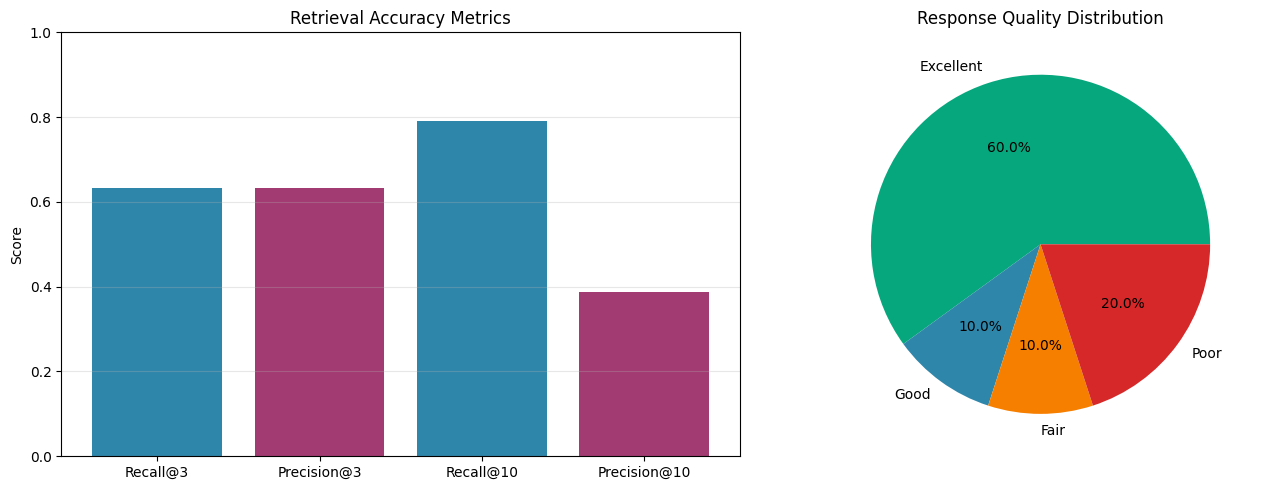

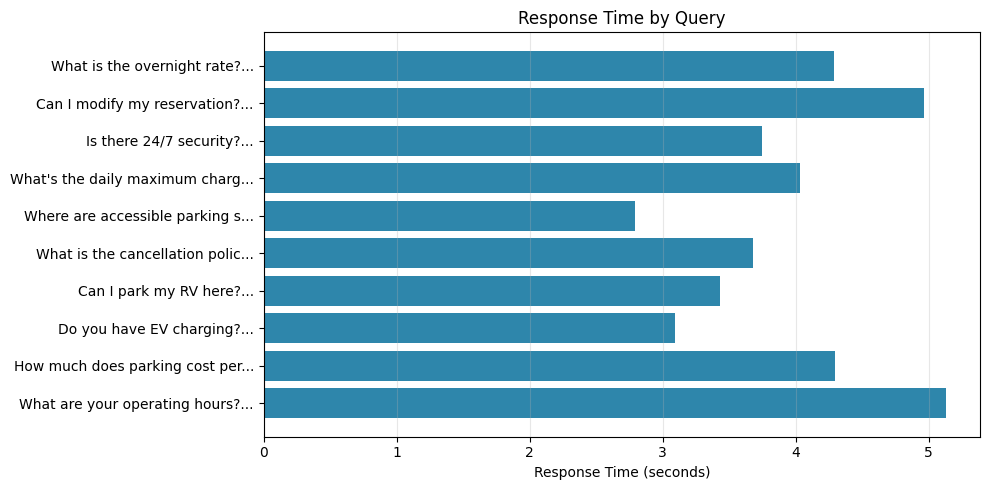

In [11]:
import matplotlib.pyplot as plt

# Plot 1: Retrieval Metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recall and Precision
metrics = ['Recall@3', 'Precision@3', 'Recall@10', 'Precision@10']
values = [
    retrieval_metrics['avg_recall_at_3'],
    retrieval_metrics['avg_precision_at_3'],
    retrieval_metrics['avg_recall_at_10'],
    retrieval_metrics['avg_precision_at_10']
]

axes[0].bar(metrics, values, color=['#2E86AB', '#A23B72', '#2E86AB', '#A23B72'])
axes[0].set_ylabel('Score')
axes[0].set_title('Retrieval Accuracy Metrics')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Response Quality Distribution
quality_labels = ['Excellent', 'Good', 'Fair', 'Poor']
quality_counts = [
    e2e_metrics['excellent_responses'],
    e2e_metrics['good_responses'],
    e2e_metrics['fair_responses'],
    e2e_metrics['poor_responses']
]

axes[1].pie(quality_counts, labels=quality_labels, autopct='%1.1f%%',
            colors=['#06A77D', '#2E86AB', '#F77F00', '#D62828'])
axes[1].set_title('Response Quality Distribution')

plt.tight_layout()
plt.show()

# Plot 2: Response Times
fig, ax = plt.subplots(figsize=(10, 5))

queries = [r.query[:30] + "..." for r in e2e_results]
times = [r.total_time for r in e2e_results]

ax.barh(queries, times, color='#2E86AB')
ax.set_xlabel('Response Time (seconds)')
ax.set_title('Response Time by Query')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

✅ **Evaluation Complete!**

**Key Findings:**
- Retrieval system evaluated with Recall@K and Precision@K metrics
- End-to-end response quality assessed
- Performance benchmarks established
- Detailed report saved to `evaluation_report.json`

**Next Steps:**
- Review low-scoring queries
- Fine-tune retrieval parameters if needed
- Monitor performance in production
- Expand test dataset as system evolves